In [1]:
import numpy as np #  algebre lineaire
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt #dataviz
import seaborn as sns  #dataviz
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score
)





In [ ]:
df = pd.read_csv('student_performance_2000.csv')

In [ ]:
df.head()

,study_hours_per_week,attendance_percent,previous_grade,absences,internet_access,extracurricular_activity,result
0,7,59.0,85.0,5,Yes,No,Fail
1,4,79.0,58.0,14,Yes,Yes,Fail
2,13,74.0,50.0,2,Yes,No,Pass
3,15,88.0,52.0,5,Yes,Yes,Pass
4,11,69.0,85.0,2,Yes,No,Pass


In [ ]:
df.columns

Index(['study_hours_per_week', 'attendance_percent', 'previous_grade',
       'absences', 'internet_access', 'extracurricular_activity', 'result'],
      dtype='object')

In [ ]:
df.shape

(2005, 7)

In [ ]:
df.isnull().sum()

,0
study_hours_per_week,0
attendance_percent,15
previous_grade,15
absences,0
internet_access,15
extracurricular_activity,15
result,0


In [ ]:
df=df.dropna(subset=['attendance_percent'])

In [ ]:
df=df.dropna(subset=['previous_grade'])

In [ ]:
df=df.dropna(subset=['internet_access'])

In [ ]:
df=df.dropna(subset=['extracurricular_activity'])

In [ ]:
df.isnull().sum()

,0
study_hours_per_week,0
attendance_percent,0
previous_grade,0
absences,0
internet_access,0
extracurricular_activity,0
result,0


In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df=df.drop_duplicates(subset=None, keep='first', inplace=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1940 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   study_hours_per_week      1940 non-null   int64  
 1   attendance_percent        1940 non-null   float64
 2   previous_grade            1940 non-null   float64
 3   absences                  1940 non-null   int64  
 4   internet_access           1940 non-null   object 
 5   extracurricular_activity  1940 non-null   object 
 6   result                    1940 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 121.2+ KB


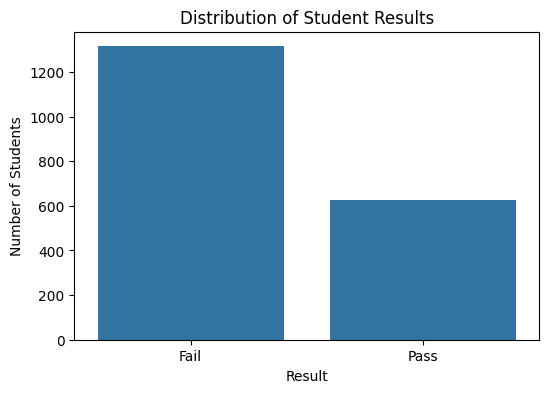

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="result")

plt.title("Distribution of Student Results")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
df.head()

,study_hours_per_week,attendance_percent,previous_grade,absences,internet_access,extracurricular_activity,result
0,7,59.0,85.0,5,Yes,No,Fail
1,4,79.0,58.0,14,Yes,Yes,Fail
2,13,74.0,50.0,2,Yes,No,Pass
3,15,88.0,52.0,5,Yes,Yes,Pass
4,11,69.0,85.0,2,Yes,No,Pass


In [ ]:
df['internet_access'] = df['internet_access'].replace({'No': 0, 'Yes': 1})

/tmp/ipykernel_2180/2818433104.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['internet_access'] = df['internet_access'].replace({'No': 0, 'Yes': 1})


In [ ]:
df['extracurricular_activity'] = df['extracurricular_activity'].replace({'No': 0, 'Yes': 1})

/tmp/ipykernel_2180/696613999.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['extracurricular_activity'] = df['extracurricular_activity'].replace({'No': 0, 'Yes': 1})


In [ ]:
df['result'] = df['result'].replace({'Fail': 0, 'Pass': 1})

/tmp/ipykernel_2180/3461770564.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['result'] = df['result'].replace({'Fail': 0, 'Pass': 1})


In [ ]:
df.head()

,study_hours_per_week,attendance_percent,previous_grade,absences,internet_access,extracurricular_activity,result
0,7,59.0,85.0,5,1,0,0
1,4,79.0,58.0,14,1,1,0
2,13,74.0,50.0,2,1,0,1
3,15,88.0,52.0,5,1,1,1
4,11,69.0,85.0,2,1,0,1


In [ ]:
X = df.drop('result', axis=1)
y = df['result']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train, y_train = SMOTE(random_state=42).fit_resample(
    X_train, y_train
)

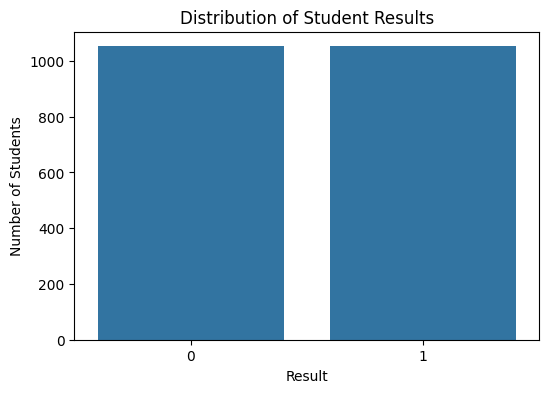

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=y_train)

plt.title("Distribution of Student Results")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

 **random forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# **Évaluation des 3 modèles**

In [ ]:
def evaluate_model(name, y_test, y_pred, y_proba):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    loss = log_loss(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n===== {name} =====")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"Log Loss  : {loss:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

In [ ]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_proba_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_proba_rf
)
evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_proba_dt
)


===== Logistic Regression =====
Accuracy  : 0.8814
Precision : 0.7970
Recall    : 0.8480
F1-score  : 0.8217
Log Loss  : 0.2792
ROC-AUC   : 0.9496

===== Random Forest =====
Accuracy  : 0.8634
Precision : 0.7687
Recall    : 0.8240
F1-score  : 0.7954
Log Loss  : 0.3130
ROC-AUC   : 0.9391

===== Decision Tree =====
Accuracy  : 0.8144
Precision : 0.6732
Recall    : 0.8240
F1-score  : 0.7410
Log Loss  : 0.6708
ROC-AUC   : 0.8925
